In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TRADING_DAYS = 252
RISK_FREE_RATE = 0.02

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", None)


In [3]:
prices = pd.read_csv(
    "../data/raw/stock_prices_20260102.csv",
    index_col=0,
    parse_dates=True
)

returns = prices.pct_change().dropna()


In [4]:
cov_matrix = returns.cov() * TRADING_DAYS


In [5]:
historical_expected_returns = returns.mean() * TRADING_DAYS

In [6]:
forecast_df = pd.read_csv(
    "../data/processed/forecasted_returns.csv",
    index_col=0
)

forecast_expected_returns = forecast_df["annualized_return"]

In [7]:
def portfolio_performance(weights, expected_returns, cov_matrix):
    port_return = np.dot(weights, expected_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - RISK_FREE_RATE) / port_vol
    return port_return, port_vol, sharpe


In [8]:
def optimize_portfolio(expected_returns, cov_matrix, n_portfolios=20000):
    n_assets = len(expected_returns)

    results = np.zeros((n_portfolios, 3))
    weights_list = []

    for i in range(n_portfolios):
        weights = np.random.random(n_assets)
        weights /= weights.sum()

        ret, vol, sharpe = portfolio_performance(
            weights, expected_returns, cov_matrix
        )

        results[i] = [ret, vol, sharpe]
        weights_list.append(weights)

    results_df = pd.DataFrame(
        results, columns=["return", "volatility", "sharpe"]
    )

    max_idx = results_df["sharpe"].idxmax()

    return {
        "weights": pd.Series(
            weights_list[max_idx],
            index=expected_returns.index
        ),
        "metrics": results_df.loc[max_idx]
    }


In [9]:
historical_portfolio = optimize_portfolio(
    historical_expected_returns,
    cov_matrix
)

historical_portfolio["weights"]


AAPL     0.0669
AMZN     0.0296
GOOGL    0.2969
META     0.1802
MSFT     0.0013
NVDA     0.2937
SPY      0.1215
TSLA     0.0099
dtype: float64

In [10]:
forecast_portfolio = optimize_portfolio(
    forecast_expected_returns,
    cov_matrix
)

forecast_portfolio["weights"]


AAPL     0.3328
AMZN     0.0341
GOOGL    0.3917
META     0.0193
MSFT     0.0407
NVDA     0.0152
SPY      0.0893
TSLA     0.0768
dtype: float64

In [11]:
weights_comparison = pd.DataFrame({
    "Historical": historical_portfolio["weights"],
    "Forecast": forecast_portfolio["weights"]
})

weights_comparison


,Historical,Forecast
AAPL,0.0669,0.3328
AMZN,0.0296,0.0341
GOOGL,0.2969,0.3917
META,0.1802,0.0193
MSFT,0.0013,0.0407
NVDA,0.2937,0.0152
SPY,0.1215,0.0893
TSLA,0.0099,0.0768


In [12]:
comparison_metrics = pd.DataFrame({
    "Historical Portfolio": historical_portfolio["metrics"],
    "Forecast Portfolio": forecast_portfolio["metrics"]
})

comparison_metrics


,Historical Portfolio,Forecast Portfolio
return,0.6084,0.4763
volatility,0.2791,0.2332
sharpe,2.1080,1.9569


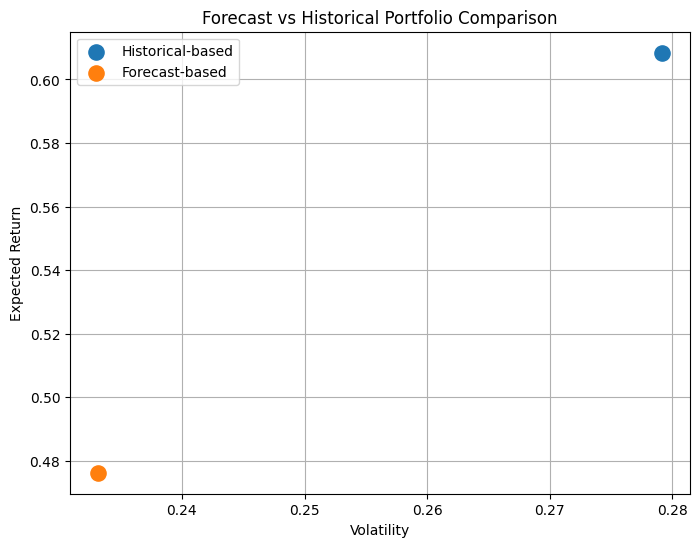

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    historical_portfolio["metrics"]["volatility"],
    historical_portfolio["metrics"]["return"],
    label="Historical-based",
    s=120
)

plt.scatter(
    forecast_portfolio["metrics"]["volatility"],
    forecast_portfolio["metrics"]["return"],
    label="Forecast-based",
    s=120
)

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Forecast vs Historical Portfolio Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
# Equal Weight portfolio metrics
equal_weight_return = eq_portfolio_returns.mean() * 252
equal_weight_vol = eq_portfolio_returns.std() * np.sqrt(252)
equal_weight_sharpe = equal_weight_return / equal_weight_vol

# summary용 변수명 통일
eq_return = equal_weight_return
eq_vol = equal_weight_vol
eq_sharpe = equal_weight_sharpe


NameError: name 'eq_portfolio_returns' is not defined

In [14]:
summary = pd.DataFrame({
    "Return": {
        "Equal Weight": eq_return,
        "Historical": hist_return,
        "Forecast": forecast_return
    },
    "Volatility": {
        "Equal Weight": eq_vol,
        "Historical": hist_vol,
        "Forecast": forecast_vol
    },
    "Sharpe": {
        "Equal Weight": eq_sharpe,
        "Historical": hist_sharpe,
        "Forecast": forecast_sharpe
    }
})

summary.to_csv("../data/processed/portfolio_summary.csv")
summary


NameError: name 'eq_return' is not defined